In [1]:
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image, display
from PIL import ImageDraw
from PIL import Image as PILImage

Imagen seleccionada: 14042507CN_jpg.rf.3fb2526edeac9c97310b2f71145f0d30.jpg


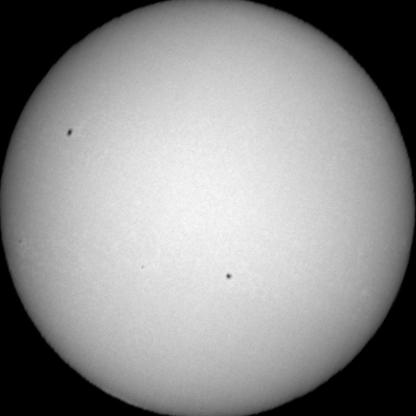

In [3]:
images_path = Path('dataset/OGAUC/train/images')
image_files = list(images_path.glob('*.jpg'))
img_path = random.choice(image_files)

# Mostrar la imagen original
print(f"Imagen seleccionada: {img_path.name}")
display(Image(filename=str(img_path)))


In [4]:
def nothing(x):
    pass

def interactive_sunspot_remove_disk(image_path):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    cv2.namedWindow('Segmentación Sunspot')
    cv2.createTrackbar('BlockSize', 'Segmentación Sunspot', 17, 101, nothing)  # impar
    cv2.createTrackbar('C', 'Segmentación Sunspot', 10, 20, nothing)
    cv2.createTrackbar('Area%', 'Segmentación Sunspot', 2, 20, nothing)  # 0.01 a 0.20

    while True:
        block_size = cv2.getTrackbarPos('BlockSize', 'Segmentación Sunspot')
        c = cv2.getTrackbarPos('C', 'Segmentación Sunspot')
        area_percent = cv2.getTrackbarPos('Area%', 'Segmentación Sunspot')
        # Ajustes
        if block_size % 2 == 0:
            block_size += 1
        if block_size < 3:
            block_size = 3
        area_ratio = area_percent / 100.0
        # Umbralización adaptativa
        thresh = cv2.adaptiveThreshold(
            img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV, block_size, c
        )
        # Eliminar bordes grandes
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        min_area = area_ratio * img.shape[0] * img.shape[1]
        mask = np.ones_like(thresh) * 255
        for cnt in contours:
            if cv2.contourArea(cnt) > min_area:
                cv2.drawContours(mask, [cnt], -1, 0, thickness=cv2.FILLED)
        result = cv2.bitwise_and(thresh, mask)
        cv2.imshow('Segmentación Sunspot', result)
        k = cv2.waitKey(1) & 0xFF
        if k == 27:  # ESC para salir
            break
    cv2.destroyAllWindows()

# Uso:
interactive_sunspot_remove_disk(img_path)

In [5]:
def segment_sunspot_remove_disk(image_path, block_size=101, c=10, area_ratio=0.02):
    if block_size % 2 == 0:
        block_size += 1
    if block_size < 3:
        block_size = 3
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    thresh = cv2.adaptiveThreshold(
        img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, block_size, c
    )
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    min_area = area_ratio * img.shape[0] * img.shape[1]
    mask = np.ones_like(thresh) * 255
    for cnt in contours:
        if cv2.contourArea(cnt) > min_area:
            cv2.drawContours(mask, [cnt], -1, 0, thickness=cv2.FILLED)
    result = cv2.bitwise_and(thresh, mask)
    pil_img = PILImage.fromarray(result)
    return pil_img

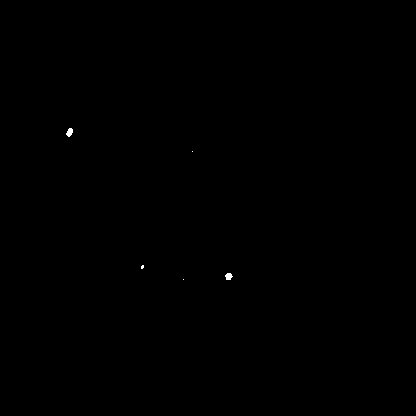

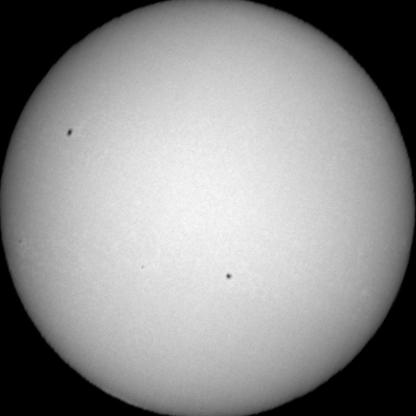

In [6]:
seg_img = segment_sunspot_remove_disk(img_path, block_size=101, c=10, area_ratio=0.02)
display(seg_img)
display(Image(filename=str(img_path)))

In [7]:
def get_bboxes_from_mask(mask, min_spot_area=2):
    # Asegúrate de que mask es un array numpy uint8
    if not isinstance(mask, np.ndarray):
        mask = np.array(mask)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bboxes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > min_spot_area:
            x, y, w, h = cv2.boundingRect(cnt)
            bboxes.append((x, y, w, h))
    return bboxes

In [8]:
def draw_bboxes_on_image(image_path, bboxes):
    pil_img = PILImage.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(pil_img)
    for (x, y, w, h) in bboxes:
        draw.rectangle([x, y, x+w, y+h], outline="red", width=2)
    return pil_img

In [9]:
def expand_bboxes(bboxes, img_shape, margin=5):
    """
    Expande cada bbox por 'margin' píxeles en cada dirección, sin salirse de la imagen.
    bboxes: lista de (x, y, w, h)
    img_shape: (alto, ancho)
    """
    h, w = img_shape
    expanded = []
    for (x, y, bw, bh) in bboxes:
        x0 = max(x - margin, 0)
        y0 = max(y - margin, 0)
        x1 = min(x + bw + margin, w)
        y1 = min(y + bh + margin, h)
        expanded.append((x0, y0, x1 - x0, y1 - y0))
    return expanded

Bounding boxes: [(225, 273, 8, 7), (141, 265, 3, 4), (66, 128, 7, 9)]


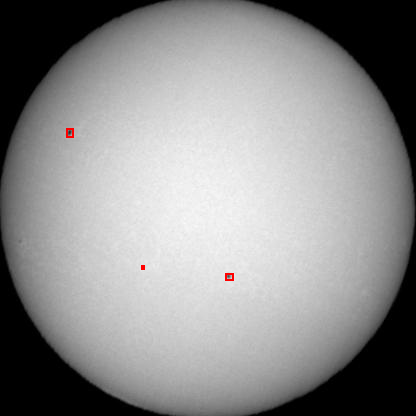

In [10]:
mask_np = np.array(seg_img)

bboxes = get_bboxes_from_mask(mask_np, min_spot_area=2)
print("Bounding boxes:", bboxes)

img_with_bboxes = draw_bboxes_on_image(str(img_path), bboxes)
display(img_with_bboxes)

Bounding boxes (expandidos): [(220, 268, 18, 17), (136, 260, 13, 14), (61, 123, 17, 19)]


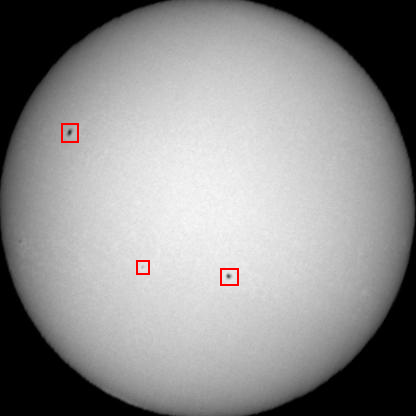

In [12]:
bboxes_expanded = expand_bboxes(bboxes, mask_np.shape, margin=5)
print("Bounding boxes (expandidos):", bboxes_expanded)

img_with_bboxes = draw_bboxes_on_image(str(img_path), bboxes_expanded)
display(img_with_bboxes)